## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Loading Dataset

In [2]:
df = pd.read_csv(r'D:\My Course Ai Bin\Machine Learning\Linear\Fish[1].csv')
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


## EDA

In [3]:
df.shape

(159, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


## Checking Missing Values

In [6]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [8]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

## Removing Categorical Columns 

In [ ]:
df = df.drop('Species', axis=1)
df.head()

,Weight,Length1,Length2,Length3,Height,Width
0,242.0,23.2,25.4,30.0,11.5200,4.0200
1,290.0,24.0,26.3,31.2,12.4800,4.3056
2,340.0,23.9,26.5,31.1,12.3778,4.6961
3,363.0,26.3,29.0,33.5,12.7300,4.4555
4,430.0,26.5,29.0,34.0,12.4440,5.1340


## Data Visulaization 

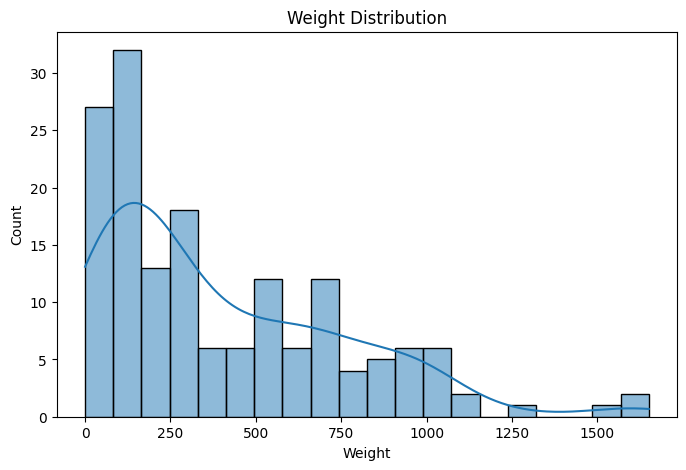

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Weight'], bins=20, kde=True)
plt.title('Weight Distribution')
plt.xlabel('Weight')
plt.ylabel('Count')
plt.show()

## Correlation Heatmap 

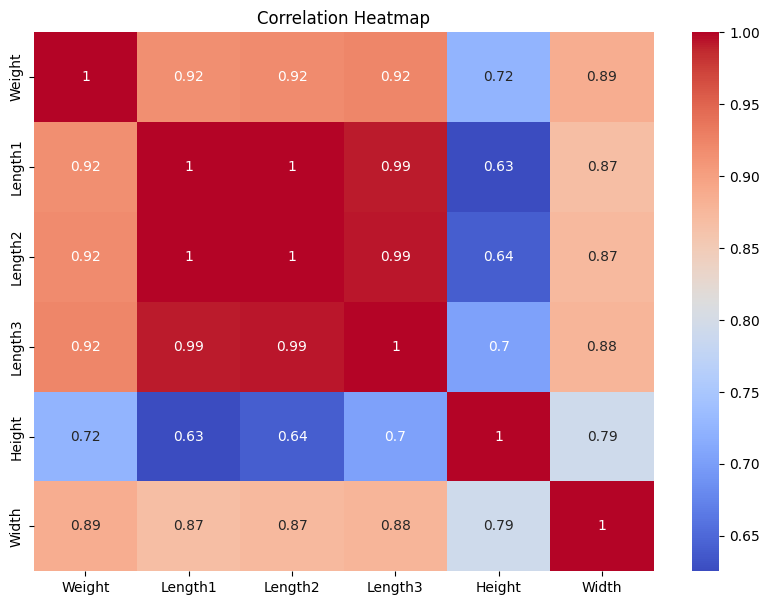

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Scatter Plot 

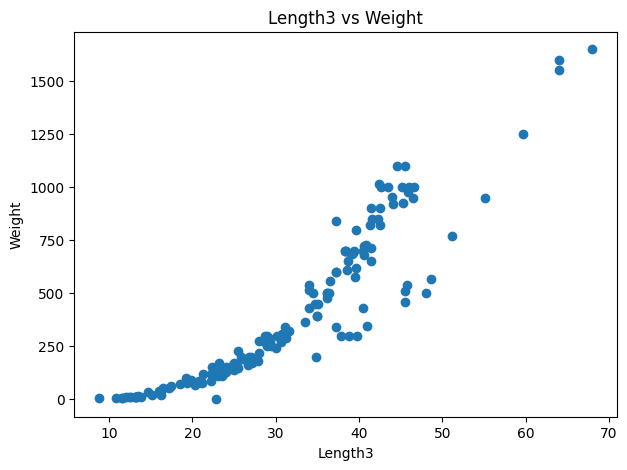

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(df['Length3'], df['Weight'])
plt.title('Length3 vs Weight')
plt.xlabel('Length3')
plt.ylabel('Weight')
plt.show()

## Features and Target 

In [ ]:
X = df.drop('Weight', axis=1)
y = df['Weight']
print('Features Shape:', X.shape)
print('Target Shape:', y.shape)

Features Shape: (159, 5)
Target Shape: (159,)


## Splitting Dataset 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print('Training Data Shape:', X_train.shape)
print('Testing Data Shape:', X_test.shape)

Training Data Shape: (127, 5)
Testing Data Shape: (32, 5)


## Train Linear Regresssion Model 

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Model Training Completed')

Model Training Completed


## Make Predictions 

In [ ]:
y_pred = model.predict(X_test)
prediction_df = pd.DataFrame({
    'Actual Values': y_test,
    'Predicted Values': y_pred
})
prediction_df.head()

,Actual Values,Predicted Values
78,78.0,77.685633
155,13.4,-159.124606
128,200.0,385.167355
55,270.0,300.261194
94,150.0,179.410232


## Model Evalution 

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)

Mean Absolute Error: 103.909417084223
Mean Squared Error: 16763.887193140756
R2 Score: 0.8821430593048694


## Actual vs Predicted Visualization

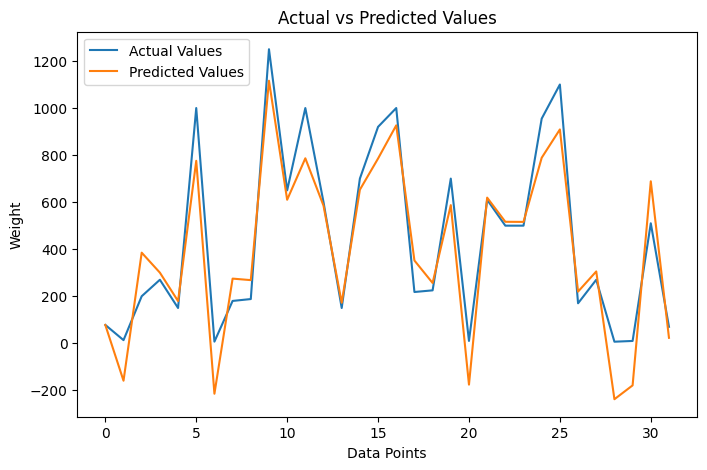

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label='Actual Values')
plt.plot(y_pred, label='Predicted Values')
plt.title('Actual vs Predicted Values')
plt.xlabel('Data Points')
plt.ylabel('Weight')
plt.legend()
plt.show()

## Sample Prediction

In [ ]:
sample_data = X.iloc[[5]]
prediction = model.predict(sample_data)
print('Predicted Weight:', prediction[0])

Predicted Weight: 456.6756638566303
